In [30]:
import numpy as np 
import tensorflow as tf
from tensorflow.keras import layers, models

[5 0 4 ... 5 6 8]
42000 42000
18000 18000
Model 1 Training Data: (42000, 28, 28, 1), Labels: (42000,)
Model 2 Training Data: (18000, 28, 28, 1), Labels: (18000,)


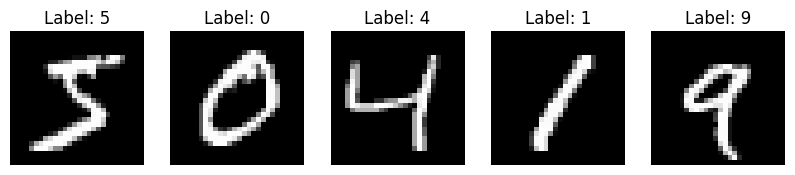

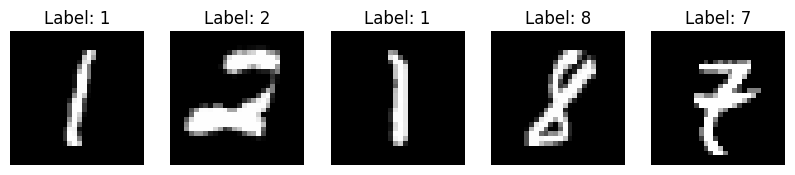

In [44]:
import matplotlib.pyplot as plt

# Function to read .ubyte dataset
def read_idx(filename):
    with open(filename, 'rb') as f:
        data = f.read()
        magic = int.from_bytes(data[0:4], 'big')
        size = int.from_bytes(data[4:8], 'big')
        if magic == 2051:  # Images
            rows = int.from_bytes(data[8:12], 'big')
            cols = int.from_bytes(data[12:16], 'big')
            images = np.frombuffer(data, dtype=np.uint8, offset=16).reshape(size, rows, cols)
            return images
        elif magic == 2049:  # Labels
            labels = np.frombuffer(data, dtype=np.uint8, offset=8)
            return labels

# Load the dataset
train_images_path = './MNIST/train-images-idx3-ubyte'
train_labels_path = './MNIST/train-labels-idx1-ubyte'

x = read_idx(train_images_path)  # Load images
y = read_idx(train_labels_path)  # Load labels
print(y)

# Normalize and reshape the data
x = x / 255.0
x = x.reshape(-1, 28, 28, 1)

# Split the dataset manually into 70% for Model 1 and 30% for Model 2
split_index = int(0.7 * len(x))  # Calculate 70% split index

x_train_1, y_train_1 = x[:split_index], y[:split_index]  # Model 1 dataset
x_train_2, y_train_2 = x[split_index:], y[split_index:]  # Model 2 dataset
print(len(x_train_1),len(y_train_1))
print(len(x_train_2),len(y_train_2))

# Verify the splits
print(f"Model 1 Training Data: {x_train_1.shape}, Labels: {y_train_1.shape}")
print(f"Model 2 Training Data: {x_train_2.shape}, Labels: {y_train_2.shape}")

# Display the first 5 images in the x_train_1 dataset
def show_images(images, labels):
    plt.figure(figsize=(10, 10))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.show()

# Show the first 5 images from Model 1 dataset (x_train_1)
show_images(x_train_1, y_train_1)
show_images(x_train_2, y_train_2)


In [32]:
#Model 1
# Define the second CNN architecture
def cnn_model_1():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Compile and train the second CNN using the last 30% of the dataset
model2 = cnn_model_1()
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()
model2.fit(x_train_1, y_train_1, epochs=10, batch_size=64)


# Evaluate both models on their respective datasets

print("\nEvaluating Model 1 on its training data:")
model2.evaluate(x_train_1, y_train_1)

# Save both models

model2.save('mnist_cnn-same-arch_model1_70split.keras')

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_15 (MaxPoolin  (None, 13, 13, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_16 (MaxPoolin  (None, 5, 5, 64)         0         
 g2D)                                                            
                                                                 
 flatten_5 (Flatten)         (None, 1600)              0         
                                                                 
 dense_15 (Dense)            (None, 64)               

In [33]:
#Model 2
# Define the second CNN architecture
def cnn_model_2():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Compile and train the second CNN using the last 30% of the dataset
model2 = cnn_model_2()
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()
model2.fit(x_train_2, y_train_2, epochs=10, batch_size=64)


# Evaluate both models on their respective datasets

print("\nEvaluating Model 2 on its training data:")
model2.evaluate(x_train_2, y_train_2)

# Save both models

model2.save('mnist_cnn-same-arch_model2_30split.keras')

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_17 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_17 (MaxPoolin  (None, 13, 13, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_18 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_18 (MaxPoolin  (None, 5, 5, 64)         0         
 g2D)                                                            
                                                                 
 flatten_6 (Flatten)         (None, 1600)              0         
                                                                 
 dense_17 (Dense)            (None, 64)               

In [36]:
#Combining Weights
model1 = load_model('./mnist_cnn-same-arch_model1_70split.keras')
model2 = load_model('./mnist_cnn-same-arch_model2_30split.keras')

#layer 0
a0=model1.layers[0].get_weights()
b0=model2.layers[0].get_weights()
layer_0=[(np.add(a0[i],b0[i]))/2 for i in range(len(a0))]

#layer 2
a2=model1.layers[2].get_weights()
b2=model2.layers[2].get_weights()
layer_2=[(np.add(a2[i],b2[i]))/2 for i in range(len(a2))]

#layer 5
a5=model1.layers[5].get_weights()
b5=model2.layers[5].get_weights()
layer_5=[(np.add(a5[i],b5[i]))/2 for i in range(len(a5))]

#layer 6
a6=model1.layers[6].get_weights()
b6=model2.layers[6].get_weights()
layer_6=[(np.add(a6[i],b6[i]))/2 for i in range(len(a6))]


In [37]:
#Combined Model 
c_model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])


#Setting weights
c_model.layers[0].set_weights(layer_0)#0
c_model.layers[2].set_weights(layer_2)#2
c_model.layers[5].set_weights(layer_5)#4
c_model.layers[6].set_weights(layer_6)#6

#Compile and Save
c_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
c_model.summary()

c_model.save('mnist_cnn-same-arch_combined_model.keras')

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_21 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 13, 13, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_22 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_22 (MaxPoolin  (None, 5, 5, 64)         0         
 g2D)                                                            
                                                                 
 flatten_8 (Flatten)         (None, 1600)              0         
                                                                 
 dense_21 (Dense)            (None, 64)               

In [45]:
model1 = load_model('./mnist_cnn-same-arch_model1_70split.keras')
model2 = load_model('./mnist_cnn-same-arch_model2_30split.keras')
#Federated Averaging
import numpy as np
from keras.models import load_model


# Get the model weights from sys1 and sys2
weights1 = model1.get_weights()
weights2 = model2.get_weights()

# Assume N1 and N2 are the number of samples each client has (you should replace them with actual numbers)
N1 = 42000  # Example: Number of samples for sys1
N2 = 18000  # Example: Number of samples for sys2

# Compute total number of samples
total_samples = N1 + N2

# Compute the weighted average of the model weights
weights_global = []
for w1, w2 in zip(weights1, weights2):
    weighted_w = (w1 * N1 + w2 * N2) / total_samples
    weights_global.append(weighted_w)

# Create a global model and set the aggregated weights
global_model = load_model('./mnist_cnn-same-arch_model1_70split.keras')  # Using sys1's architecture as global model
global_model.set_weights(weights_global)

wei=global_model.layers[6].get_weights()
print(wei)

# Now you can use the global model for prediction or further training
global_model.save('./fed_learn_global_model.keras')


[array([[ 2.77174532e-01,  3.24503593e-02, -1.55759111e-01,
         7.91044086e-02,  2.01586988e-02, -2.20519975e-01,
         1.02740847e-01, -7.22219571e-02, -8.47637504e-02,
        -1.02842011e-01],
       [-3.45392041e-02, -9.32168588e-02,  6.60408884e-02,
         2.55797803e-01, -1.11100800e-01,  8.08160827e-02,
        -1.38186142e-01,  7.18113855e-02,  1.68456987e-01,
         3.65586095e-02],
       [ 6.27398267e-02,  1.66012377e-01,  2.93319905e-03,
        -3.65539007e-02, -3.70347291e-01, -1.88689873e-01,
        -2.93339547e-02, -2.20301643e-01,  1.25313802e-02,
         6.86331540e-02],
       [ 1.06308959e-01,  8.15216899e-02,  8.48601535e-02,
        -2.50324786e-01, -4.45577316e-02, -1.87390491e-01,
        -4.52205393e-04, -4.40796874e-02, -6.06866740e-02,
        -5.26799560e-02],
       [-1.97423678e-02,  2.09673911e-01,  1.99128464e-02,
         1.56142086e-01, -2.54271567e-01,  1.87513173e-01,
        -2.31066905e-03, -1.33876139e-02, -1.54156789e-01,
        -1

In [43]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load the saved models
model1 = load_model('./mnist_cnn-same-arch_model1_70split.keras')
model2 = load_model('./mnist_cnn-same-arch_model2_30split.keras')
c_model = load_model('./mnist_cnn-same-arch_combined_model.keras')
fed_model = load_model('./fed_learn_global_model.keras')

# Function to preprocess the uploaded image using OpenCV
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read the image in grayscale
    img = cv2.resize(img, (28, 28))                     # Resize to 28x28
    img_array = img / 255.0                             # Normalize pixel values to [0, 1]
    img_array = img_array.reshape(1, 28, 28, 1)         # Add batch dimension
    return img_array

# Function to predict the digit using a specific model
def predict_digit(model, image):
    prediction = model.predict(image)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    return predicted_digit, confidence

# Upload and predict
def predict_uploaded_image(image_path):
    # Preprocess the image
    processed_image = preprocess_image(image_path)
    
    # Predict using Model 1
    predicted_digit_1, confidence_1 = predict_digit(model1, processed_image)
    print(f"Model 1 Prediction: {predicted_digit_1} with confidence {confidence_1:.2f}%")
    
    # Predict using Model 2
    predicted_digit_2, confidence_2 = predict_digit(model2, processed_image)
    print(f"Model 2 Prediction: {predicted_digit_2} with confidence {confidence_2:.2f}%")

    predicted_digit_3, confidence_3 = predict_digit(c_model, processed_image)
    print(f"Combined Model  Prediction: {predicted_digit_3} with confidence {confidence_3:.2f}%")

    predicted_digit_4, confidence_4 = predict_digit(fed_model, processed_image)
    print(f"Federated Model  Prediction: {predicted_digit_4} with confidence {confidence_4:.2f}%")

# Example image path
image_path = './5.jpeg'
predict_uploaded_image(image_path)


1/1 [==============================] - 0s 191ms/step
Model 1 Prediction: 5 with confidence 52.40%
1/1 [==============================] - 0s 211ms/step
Model 2 Prediction: 8 with confidence 74.92%
1/1 [==============================] - 0s 203ms/step
Combined Model  Prediction: 8 with confidence 11.05%
1/1 [==============================] - 0s 205ms/step
Federated Model  Prediction: 6 with confidence 14.17%


In [ ]:
#Bro is worse no mattuh what ;(